# Prediksi Harga Laptop Berdasarkan Spesifikasi

##1. IMPORT LIBRARY
Tahap ini mengimpor semua library yang dibutuhkan untuk proses analisis data, visualisasi, preprocessing, modeling, evaluasi, dan menyimpan dan memuat model Machine siap di deploy.

In [50]:
import pandas as pd
import numpy as np
# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# menyimpan dan memuat model Machine
import joblib

##2. DATA UNDERSTANDING
Tahap Data Understanding bertujuan untuk memahami dataset yang digunakan sebelum dilakukan pengolahan lebih lanjut. Pada tahap ini dilakukan identifikasi sumber data, penjelasan fitur, serta analisis statistik deskriptif untuk mengetahui karakteristik data.
- **Sumber Dataset**: Dataset yang digunakan dalam penelitian ini diperoleh dari platform Kaggle dengan judul Laptop Price Prediction. Dataset ini berisi informasi spesifikasi laptop dan harga yang digunakan sebagai target prediksi.Dataset diperoleh dari Kaggle:https://www.kaggle.com/code/juanzi/laptop-price-prediction/input

- **Fitur/Variabel**:
Fitur dalam dataset ini meliputi karakteristik utama laptop seperti Processor_Speed (kecepatan prosesor), RAM_Size (kapasitas RAM), Storage_Capacity (kapasitas penyimpanan), Screen_Size (ukuran layar), Weight (berat laptop), serta Brand (merek laptop). Variabel-variabel ini digunakan sebagai faktor yang mempengaruhi harga laptop.
Target utama dalam penelitian ini adalah Price, yaitu harga laptop yang akan diprediksi menggunakan model Machine Learning.

- **Memuat Dataset & Melihat Data Awal**: Langkah ini dilakukan untuk memastikan dataset berhasil dimuat serta melihat beberapa baris pertama data.


In [ ]:
# 2. LOAD DATA
df = pd.read_csv('/content/Laptop_price (1).csv')

df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


- **Informasi Struktur Data**
Digunakan untuk melihat jumlah data, tipe data tiap kolom, serta mendeteksi missing value.

In [ ]:
print("\nINFO DATA")
print(df.info())


INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB
None


- **Statistik Deskriptif**
Digunakan untuk melihat ringkasan statistik seperti rata-rata, nilai minimum, maksimum, dan standar deviasi.

In [ ]:
print("\nDESKRIPSI DATA")
print(df.describe())



DESKRIPSI DATA
       Processor_Speed     RAM_Size  Storage_Capacity  Screen_Size  \
count      1000.000000  1000.000000       1000.000000  1000.000000   
mean          2.750611    15.500000        584.576000    14.056790   
std           0.731796    10.988665        313.438517     1.705882   
min           1.511580     4.000000        256.000000    11.012111   
25%           2.089246     8.000000        256.000000    12.635523   
50%           2.760885    16.000000        512.000000    14.099643   
75%           3.362610    32.000000       1000.000000    15.528590   
max           3.998534    32.000000       1000.000000    16.985737   

            Weight         Price  
count  1000.000000   1000.000000  
mean      3.466919  19604.187963  
std       0.866541   9406.064880  
min       2.000560   8570.012950  
25%       2.717211  10114.012948  
50%       3.464630  17287.241878  
75%       4.212583  31566.214754  
max       4.990728  33503.935037  


- **Cek Missing Value**
Digunakan untuk memastikan tidak ada data yang hilang.

In [ ]:
print("\nMISSING VALUE")
print(df.isnull().sum())


MISSING VALUE
Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64


- **Cek Duplikasi Data**
Digunakan untuk mengetahui apakah terdapat data yang sama (duplikat).

In [ ]:
print("\nDUPLIKAT")
print(df.duplicated().sum())


DUPLIKAT
0


##3. DATA PREPROCESSING
Membersihkan data dengan menghapus duplikasi dan mengubah variabel kategorikal menjadi numerik menggunakan encoding.

In [ ]:
# Hapus duplikat jika ada
df = df.drop_duplicates()

In [ ]:
# Encoding kolom kategorikal
df = pd.get_dummies(df, columns=["Brand"], drop_first=True)

## 4. EXPLORATORY DATA ANALYSIS (EDA)
Visualisasi digunakan untuk memahami distribusi data, mendeteksi outlier, dan melihat hubungan antar variabel.

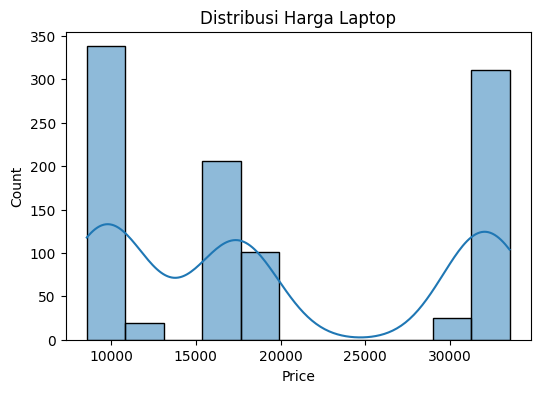

In [ ]:
# Histogram Price
plt.figure(figsize=(6,4))
sns.histplot(df["Price"], kde=True)
plt.title("Distribusi Harga Laptop")
plt.show()

### Penjelasan Output:
Plot histogram ini menunjukkan distribusi harga laptop. Kurva KDE (Kernel Density Estimate) yang menyertainya mengindikasikan bahwa distribusi harga cenderung miring ke kanan (right-skewed), dengan sebagian besar harga terkonsentrasi pada rentang yang lebih rendah dan ekor panjang menuju harga yang lebih tinggi. Ini menunjukkan adanya outlier harga tinggi atau variasi harga yang signifikan.

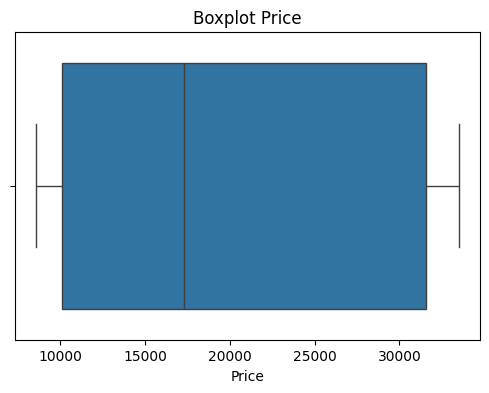

In [ ]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Price"])
plt.title("Boxplot Price")
plt.show()


### Penjelasan Output:
Boxplot ini menampilkan ringkasan statistik (median, kuartil, pencilan) dari kolom 'Price'. Garis tengah menunjukkan median, kotak menunjukkan rentang interkuartil (IQR), dan titik-titik di luar "whisker" menunjukkan pencilan (outliers). Boxplot ini mengkonfirmasi adanya pencilan dengan nilai tinggi, yang juga terlihat dari histogram sebelumnya.

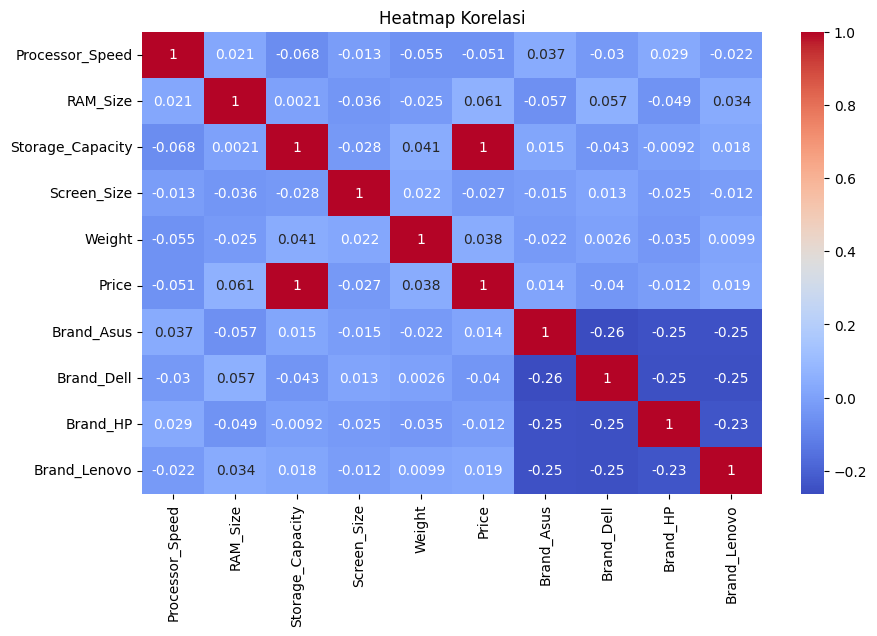

In [ ]:
# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()

In [ ]:
corr_price = df.corr(numeric_only=True)['Price'].sort_values(ascending=False)
print(corr_price)

Price               1.000000
Storage_Capacity    0.997908
Price_log           0.986818
RAM_Size            0.061237
Weight              0.038417
Brand_Lenovo        0.019099
Brand_Asus          0.013548
Brand_HP           -0.012077
Screen_Size        -0.026740
Brand_Dell         -0.040482
Processor_Speed    -0.050737
Name: Price, dtype: float64


## INSIGHT PENTING DARI DATASET
Berdasarkan hasil Exploratory Data Analysis (EDA), distribusi harga laptop menunjukkan pola yang tidak normal dan cenderung miring ke kanan (right-skewed), sehingga diperlukan transformasi logaritmik untuk meningkatkan performa model.

Dari analisis boxplot, tidak ditemukan outlier ekstrem yang signifikan, sehingga seluruh data masih dapat digunakan dalam proses pemodelan.

Hasil analisis korelasi menunjukkan bahwa fitur Storage_Capacity memiliki hubungan yang sangat kuat terhadap harga laptop, dengan nilai korelasi mendekati 1. Sementara itu, fitur lain seperti RAM_Size, Weight, dan Screen_Size memiliki pengaruh yang relatif kecil.

Hal ini menunjukkan bahwa kapasitas penyimpanan merupakan faktor utama dalam menentukan harga laptop pada dataset ini.

## 5. FEATURE ENGINEERING (TRANSFORMASI)
Transformasi log digunakan untuk mengatasi distribusi harga yang tidak normal (skewed).

In [ ]:
#Transformasi log (WAJIB)
df['Price_log'] = np.log(df['Price'])

##6. PEMISAHAN FITUR DAN TARGET
Memisahkan data menjadi variabel input (X) dan target (y).

In [ ]:
# Pisahkan fitur dan target
X = df.drop(['Price', 'Price_log'], axis=1)
y = df['Price_log']

##7. DATA SPLITTING
Tahap ini membagi dataset menjadi data training dan testing dengan 3 variasi rasio. Setelah itu dilakukan scaling untuk menyesuaikan skala fitur.

In [46]:
splits = [(0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]

split_data = {}

for train_ratio, test_ratio in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_ratio, random_state=42
    )

    # Scaling (hindari data leakage)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Simpan hasil
    split_data[train_ratio] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

print("Data splitting selesai ✔")

Data splitting selesai ✔


##8. MODELING & EVALUATION (TERPISAH)
Tahap ini melatih model Machine Learning menggunakan data hasil splitting, lalu mengevaluasi performanya dengan MAE, MSE, RMSE, dan R².

In [47]:
results = []

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

# Loop setiap split
for train_ratio, data in split_data.items():

    print(f"\n=== MODELING SPLIT {train_ratio}:{1-train_ratio} ===")

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append([name, train_ratio, mae, mse, rmse, r2])

# Simpan hasil
results_df = pd.DataFrame(results, columns=["Model","Train Size","MAE","MSE","RMSE","R2"])

print("\nHASIL MODEL:")
print(results_df.sort_values(by="R2", ascending=False))


=== MODELING SPLIT 0.7:0.30000000000000004 ===

=== MODELING SPLIT 0.8:0.19999999999999996 ===

=== MODELING SPLIT 0.9:0.09999999999999998 ===

HASIL MODEL:
               Model  Train Size       MAE       MSE      RMSE        R2
8      Random Forest         0.9  0.010637  0.000196  0.013996  0.999271
5      Random Forest         0.8  0.011467  0.000236  0.015373  0.999067
2      Random Forest         0.7  0.011245  0.000238  0.015438  0.999023
7      Decision Tree         0.9  0.014250  0.000402  0.020061  0.998503
1      Decision Tree         0.7  0.015631  0.000463  0.021506  0.998103
4      Decision Tree         0.8  0.016231  0.000489  0.022110  0.998069
6  Linear Regression         0.9  0.065607  0.005689  0.075428  0.978833
3  Linear Regression         0.8  0.071064  0.006532  0.080824  0.974199
0  Linear Regression         0.7  0.071196  0.006649  0.081540  0.972734


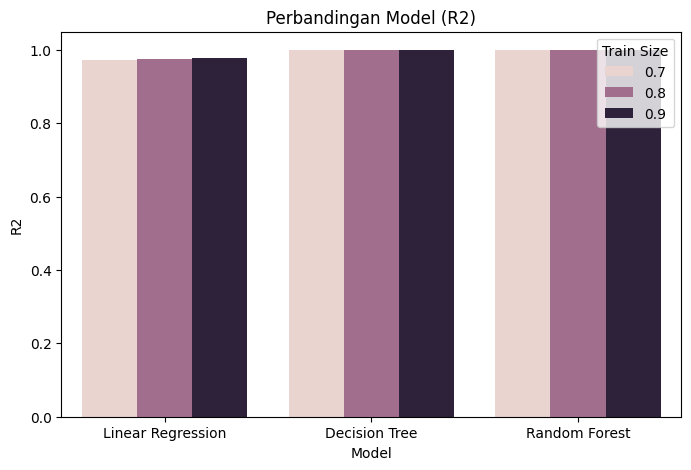

In [49]:
# Visualisasi
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R2", hue="Train Size")
plt.title("Perbandingan Model (R2)")
plt.show()

## 9. Hyperparameter Tuning
Mengoptimalkan parameter model untuk meningkatkan performa menggunakan GridSearchCV.

In [ ]:
# Gunakan split terakhir
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Decision Tree
param_dt = {'max_depth': [5, 10, 20]}
grid_dt = GridSearchCV(DecisionTreeRegressor(), param_dt, cv=5)
grid_dt.fit(X_train, y_train)

# Random Forest
param_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
grid_rf = GridSearchCV(RandomForestRegressor(), param_rf, cv=5)
grid_rf.fit(X_train, y_train)

print("\nBEST DT:", grid_dt.best_params_)
print("BEST RF:", grid_rf.best_params_)


BEST DT: {'max_depth': 5}
BEST RF: {'max_depth': 10, 'n_estimators': 50}


## 10. EVALUASI SEBELUM & SESUDAH TUNING
Membandingkan performa model sebelum dan setelah tuning untuk melihat peningkatan.

In [ ]:
# ================================
# BASELINE MODEL (SEBELUM TUNING)
# ================================

# Model default (belum tuning)
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

# Training
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluasi
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

dt_result = evaluate(y_test, y_pred_dt)
rf_result = evaluate(y_test, y_pred_rf)

print("=== SEBELUM TUNING ===")
print(f"Decision Tree -> MAE: {dt_result[0]:.2f}, RMSE: {dt_result[2]:.2f}, R2: {dt_result[3]:.4f}")
print(f"Random Forest -> MAE: {rf_result[0]:.2f}, RMSE: {rf_result[2]:.2f}, R2: {rf_result[3]:.4f}")

=== SEBELUM TUNING ===
Decision Tree -> MAE: 0.02, RMSE: 0.02, R2: 0.9980
Random Forest -> MAE: 0.01, RMSE: 0.02, R2: 0.9991


In [ ]:
# ================================
# HASIL SETELAH TUNING
# ================================

# Ambil model terbaik
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

# Prediksi
y_pred_dt_tuned = best_dt.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

# Evaluasi
dt_tuned_result = evaluate(y_test, y_pred_dt_tuned)
rf_tuned_result = evaluate(y_test, y_pred_rf_tuned)

print("\n=== SETELAH TUNING ===")
print(f"Decision Tree -> MAE: {dt_tuned_result[0]:.2f}, RMSE: {dt_tuned_result[2]:.2f}, R2: {dt_tuned_result[3]:.4f}")
print(f"Random Forest -> MAE: {rf_tuned_result[0]:.2f}, RMSE: {rf_tuned_result[2]:.2f}, R2: {rf_tuned_result[3]:.4f}")


=== SETELAH TUNING ===
Decision Tree -> MAE: 0.01, RMSE: 0.02, R2: 0.9991
Random Forest -> MAE: 0.01, RMSE: 0.02, R2: 0.9991


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Decision Tree", "Random Forest", "Random Forest"],
    "Kondisi": ["Sebelum", "Sesudah", "Sebelum", "Sesudah"],
    "R2": [dt_result[3], dt_tuned_result[3], rf_result[3], rf_tuned_result[3]],
    "RMSE": [dt_result[2], dt_tuned_result[2], rf_result[2], rf_tuned_result[2]]
})

print("\nPERBANDINGAN:")
print(comparison)


PERBANDINGAN:
           Model  Kondisi        R2      RMSE
0  Decision Tree  Sebelum  0.998024  0.022368
1  Decision Tree  Sesudah  0.999052  0.015494
2  Random Forest  Sebelum  0.999061  0.015418
3  Random Forest  Sesudah  0.999090  0.015177


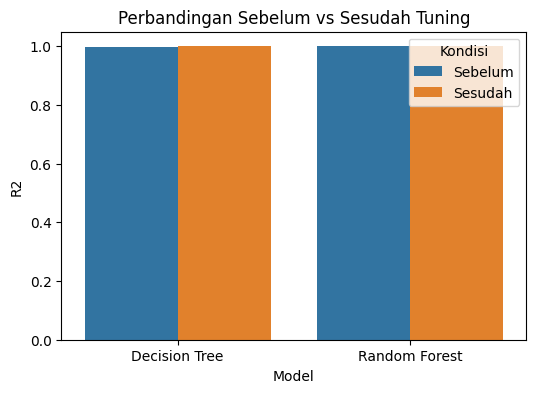

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="R2", hue="Kondisi")
plt.title("Perbandingan Sebelum vs Sesudah Tuning")
plt.show()

## 11. Feature Importance
Menentukan fitur yang paling berpengaruh terhadap harga menggunakan Random Forest.


FEATURE IMPORTANCE:
            Feature  Importance
2  Storage_Capacity    0.992775
1          RAM_Size    0.006062
0   Processor_Speed    0.000634
3       Screen_Size    0.000262
4            Weight    0.000183
5        Brand_Asus    0.000026
6        Brand_Dell    0.000023
7          Brand_HP    0.000020
8      Brand_Lenovo    0.000015


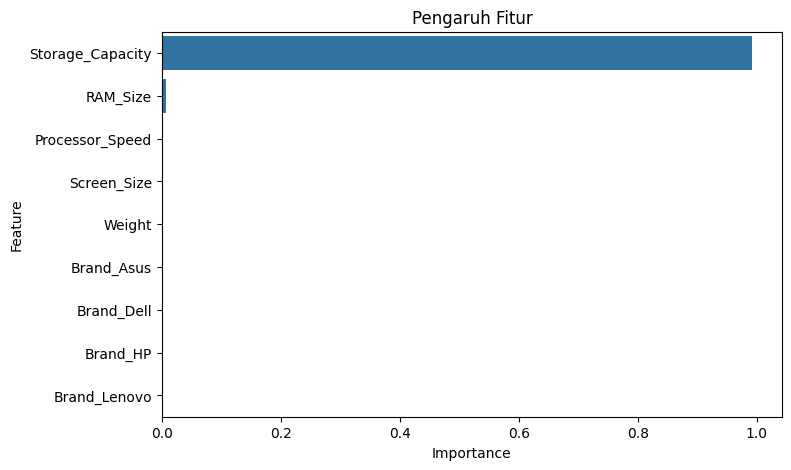

In [ ]:
best_model = grid_rf.best_estimator_

importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFEATURE IMPORTANCE:")
print(feature_importance)

# Visualisasi
plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Pengaruh Fitur")
plt.show()

## 12. Overfitting Check
Membandingkan performa model pada data training dan testing untuk mendeteksi overfitting.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

overfit = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)

    overfit.append([name, train_r2, test_r2])

overfit_df = pd.DataFrame(overfit, columns=["Model","Train R2","Test R2"])
print("\nCEK OVERFITTING:")
print(overfit_df)


CEK OVERFITTING:
               Model  Train R2   Test R2
0  Linear Regression  0.973338  0.974199
1      Decision Tree  1.000000  0.998058
2      Random Forest  0.999859  0.999068


In [51]:
# simpan model terbaik (Random Forest)
joblib.dump(best_rf, 'model_laptop.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [52]:
# Mengimpor modul 'files' dari Google Colab
from google.colab import files

# Perintah untuk mendownload file model yang sudah disimpan sebelumnya
# 'model_laptop.pkl' berisi model Machine Learning yang telah dilatih (misalnya Random Forest)
files.download('model_laptop.pkl')
# Perintah untuk mendownload file scaler
# 'scaler.pkl' digunakan untuk melakukan normalisasi data input agar sesuai dengan data saat training
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>